# Multi-Class Genomic Knowledge Distillation: Unlocking Dark Knowledge

Binary classification soft labels carry ~1 bit of dark knowledge (vs ~6.6 bits for 100 classes), which explains why logit-only KD showed ~0% gain on binary promoter classification. This notebook creates a **5-class regulatory element classification** task where teacher soft labels become genuinely informative, and standard logit KD should show clear gains.

**Classes:** Promoter (TATA), Promoter (no TATA), Enhancer, Splice Donor, Splice Acceptor

**Setup:** Set GPU T4 x 2, enable internet.

In [1]:
!pip install transformers datasets accelerate scikit-learn einops

# Configuration & Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import gc
import os
import json
import time
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BertConfig,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import load_dataset, Dataset, concatenate_datasets
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ===== Configurable Constants =====
MODEL_NAME = "quietflamingo/dnabert2-no-flashattention"
NUM_CLASSES = 5
TEACHER_EPOCHS = 8      # Eval loss minimized at epoch 2-3, prevents overfitting
MAX_LENGTH = 300
BATCH_SIZE = 16
NUM_EPOCHS = 8           # Reduced from 10 to fit Kaggle time limit
ALPHA = 0.3              # More weight on soft loss (teacher has high accuracy)
TEMPERATURE = 5.0        # Softens overconfident teacher predictions
SEED = 42

# ===== Reproducibility =====
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ===== GPU Info =====
device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count()
print(f"Device: {device}")
print(f"Number of GPUs: {num_gpus}")
for i in range(num_gpus):
    name = torch.cuda.get_device_name(i)
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem:.1f} GB)")

Device: cuda
Number of GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


# Load & Construct Multi-Class Dataset

In [ ]:
# Load full InstaDeepAI dataset
print("Loading InstaDeepAI nucleotide transformer downstream tasks...")
raw_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")

# Define task-to-class mapping (positive samples only from each binary task)
TASK_CLASS_MAP = {
    "promoter_tata": 0,
    "promoter_no_tata": 1,
    "enhancers": 2,
    "splice_sites_donors": 3,
    "splice_sites_acceptors": 4,
}
CLASS_NAMES = ["Promoter (TATA)", "Promoter (no TATA)", "Enhancer", "Splice Donor", "Splice Acceptor"]

from datasets import Features, Value

# Canonical features for our multiclass dataset (avoids int32/int64 mismatches)
MULTICLASS_FEATURES = Features({"sequence": Value("string"), "label": Value("int32")})

def collect_positives(split_data, task_name, new_label):
    """Filter for a specific task and keep only positive samples (label==1), relabeled."""
    filtered = split_data.filter(lambda ex: ex["task"] == task_name and ex["label"] == 1)
    filtered = filtered.map(lambda ex: {"sequence": ex["sequence"].upper(), "label": new_label})
    # Drop extra columns (name, task) and cast to canonical features
    filtered = filtered.remove_columns([c for c in filtered.column_names if c not in ("sequence", "label")])
    filtered = filtered.cast(MULTICLASS_FEATURES)
    return filtered

# ===== DNA AUGMENTATION FUNCTIONS =====
def augment_dna_sequence_enhanced(sequence, aug_prob=0.5):
    """Enhanced augmentation with reverse complement AND point mutations"""
    augmentations = []
    complement = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    if random.random() < aug_prob:
        rev_comp = ''.join(complement.get(b, b) for b in reversed(sequence))
        augmentations.append(rev_comp)
    if random.random() < aug_prob:
        mutated = list(sequence)
        for i in range(len(mutated)):
            if random.random() < 0.01:
                mutated[i] = random.choice(['A', 'T', 'G', 'C'])
        augmentations.append(''.join(mutated))
    return augmentations

# Collect positives for each class from train and test splits
train_parts = []
test_parts = []
for task_name, class_id in TASK_CLASS_MAP.items():
    tr = collect_positives(raw_dataset["train"], task_name, class_id)
    te = collect_positives(raw_dataset["test"], task_name, class_id)
    print(f"  {task_name}: train={len(tr)}, test={len(te)}")
    train_parts.append(tr)
    test_parts.append(te)

# ===== BALANCED SAMPLING: cap + augment to TARGET_PER_CLASS =====
# Middle ground: more data than undersampling (2,733) but not 23,905
TARGET_PER_CLASS = 6000
min_test = min(len(p) for p in test_parts)
print(f"\nTarget per class: {TARGET_PER_CLASS}")
print(f"Balancing classes...")

balanced_train_parts = []
balanced_test_parts = []
for i, (tr, te) in enumerate(zip(train_parts, test_parts)):
    if len(tr) > TARGET_PER_CLASS:
        # Downsample large classes
        tr_balanced = tr.shuffle(seed=SEED).select(range(TARGET_PER_CLASS))
        print(f"  Class {i} ({CLASS_NAMES[i]}): {len(tr)} -> {TARGET_PER_CLASS} (downsampled)")
    elif len(tr) < TARGET_PER_CLASS:
        # Augment small classes to reach target
        deficit = TARGET_PER_CLASS - len(tr)
        aug_data = {"sequence": [], "label": []}
        while len(aug_data["sequence"]) < deficit:
            idx = random.randint(0, len(tr) - 1)
            seq = tr[idx]["sequence"]
            label = int(tr[idx]["label"])
            augs = augment_dna_sequence_enhanced(seq, aug_prob=1.0)
            for aug_seq in augs:
                if len(aug_data["sequence"]) < deficit:
                    aug_data["sequence"].append(aug_seq)
                    aug_data["label"].append(label)
        aug_dataset = Dataset.from_dict(aug_data)
        aug_dataset = aug_dataset.cast(MULTICLASS_FEATURES)
        tr_balanced = concatenate_datasets([tr, aug_dataset])
        print(f"  Class {i} ({CLASS_NAMES[i]}): {len(tr)} -> {len(tr_balanced)} (augmented +{len(aug_dataset)})")
    else:
        tr_balanced = tr
        print(f"  Class {i} ({CLASS_NAMES[i]}): {len(tr)} (unchanged)")
    # Test set: undersample to smallest for fair evaluation
    te_balanced = te.shuffle(seed=SEED).select(range(min(min_test, len(te))))
    balanced_train_parts.append(tr_balanced)
    balanced_test_parts.append(te_balanced)

train_data = concatenate_datasets(balanced_train_parts).shuffle(seed=SEED)
test_data = concatenate_datasets(balanced_test_parts).shuffle(seed=SEED)

print(f"\nFinal dataset: train={len(train_data)}, test={len(test_data)}")
print("Per-class counts (train):")
for class_id, class_name in enumerate(CLASS_NAMES):
    count = sum(1 for ex in train_data if ex["label"] == class_id)
    print(f"  {class_id}: {class_name} = {count}")

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def tokenize_func(examples):
    return tokenizer(examples["sequence"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

print(f"\nTokenizing with max_length={MAX_LENGTH}...")
tokenized_train = train_data.map(tokenize_func, batched=True)
tokenized_test = test_data.map(tokenize_func, batched=True)

# Set format for PyTorch
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

train_dataset = tokenized_train
eval_dataset = tokenized_test

print(f"Tokenization complete!")
print(f"Train columns: {train_dataset.column_names}")
print(f"Sample input_ids shape: {train_dataset[0]['input_ids'].shape}")

Loading InstaDeepAI nucleotide transformer downstream tasks...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H3K14ac/train.parquet:   0%|          | 0.00/7.70M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing with max_length=300...


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete!
Train columns: ['sequence', 'labels', 'input_ids', 'attention_mask']
Sample input_ids shape: torch.Size([300])


# Train Multi-Class Teacher

In [4]:
# ===== MULTI-CLASS METRICS =====
def compute_metrics_multiclass(pred):
    labels = pred.label_ids
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


# ===== PROGRESS CALLBACK =====
class ProgressCallback(TrainerCallback):
    """Custom callback to force print output in Kaggle"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            print(f"Step {state.global_step}: {logs}", flush=True)

    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f"\n{'='*60}", flush=True)
        print(f"Starting Epoch {int(state.epoch) + 1}/{args.num_train_epochs}", flush=True)
        print(f"{'='*60}", flush=True)

    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"Epoch {int(state.epoch)} completed!", flush=True)


# ===== FINE-TUNE DNABERT-2 AS 5-CLASS TEACHER =====
print("Loading DNABERT-2 for 5-class fine-tuning...")

from transformers import AutoConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module
from safetensors.torch import load_file as load_safetensors
from huggingface_hub import hf_hub_download

# Load config and patch required fields
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.num_labels = NUM_CLASSES
config.pad_token_id = tokenizer.pad_token_id  # DNABERT-2 BertEmbeddings requires this

# Get DNABERT-2's custom model class from its auto_map
class_ref = config.auto_map["AutoModelForSequenceClassification"]
model_class = get_class_from_dynamic_module(class_ref, MODEL_NAME)

# Direct instantiation on CPU — no meta device wrapping
teacher_model = model_class(config)

# Load pretrained weights from HuggingFace hub (strict=False: classifier shape differs 2 vs 5)
try:
    weights_path = hf_hub_download(MODEL_NAME, filename="model.safetensors")
    pretrained_state = load_safetensors(weights_path)
    print("Loaded weights from model.safetensors")
except Exception:
    weights_path = hf_hub_download(MODEL_NAME, filename="pytorch_model.bin")
    pretrained_state = torch.load(weights_path, map_location="cpu", weights_only=True)
    print("Loaded weights from pytorch_model.bin")

missing, unexpected = teacher_model.load_state_dict(pretrained_state, strict=False)
print(f"Loaded pretrained weights (missing: {len(missing)}, unexpected: {len(unexpected)})")
if missing:
    print(f"  Missing (will be randomly initialized): {missing}")

teacher_params = sum(p.numel() for p in teacher_model.parameters())
print(f"Teacher parameters: {teacher_params:,} ({teacher_params/1e6:.1f}M)")

# ===== FREEZE FIRST 8 OF 12 ENCODER LAYERS =====
# Train layers 8-11 + classifier head (~35M trainable params)
# Previous run froze 10/12 layers -> teacher only reached 88.9% (too weak for KD)
# Freezing 8/12 balances overfitting prevention with enough capacity to learn
frozen_count = 0
for name, param in teacher_model.named_parameters():
    should_freeze = False
    if "embeddings" in name:
        should_freeze = True
    if "encoder.layer." in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        if layer_num < 8:
            should_freeze = True
    if should_freeze:
        param.requires_grad = False
        frozen_count += 1

trainable_params = sum(p.numel() for p in teacher_model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in teacher_model.parameters() if not p.requires_grad)
print(f"Frozen parameters: {frozen_params:,} ({frozen_params/1e6:.1f}M)")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.1f}M)")

teacher_args = TrainingArguments(
    output_dir="/kaggle/working/multiclass_teacher",
    num_train_epochs=TEACHER_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    fp16=True,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    learning_rate=2e-5,
    label_smoothing_factor=0.1,  # Produces better soft labels for KD
)

teacher_trainer = Trainer(
    model=teacher_model,
    args=teacher_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_multiclass,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        ProgressCallback(),
    ],
)

print("Starting teacher training...")
start_time = time.time()
teacher_trainer.train()
teacher_train_time = time.time() - start_time

# Evaluate teacher
teacher_metrics = teacher_trainer.evaluate()
print(f"\n--- Teacher Results ---")
print(f"  Accuracy:    {teacher_metrics['eval_accuracy']:.2%}")
print(f"  F1 (macro):  {teacher_metrics['eval_f1_macro']:.4f}")
print(f"  F1 (weighted): {teacher_metrics['eval_f1_weighted']:.4f}")
print(f"  Time:        {teacher_train_time/60:.1f} min")

# Unfreeze all layers before saving (so KD can use full model for inference)
for param in teacher_model.parameters():
    param.requires_grad = True

# Save and set to eval mode
teacher_model.save_pretrained("/kaggle/working/multiclass_teacher_final")
teacher_model.eval()
print("Teacher model saved and set to eval mode.")

# Cleanup trainer
del teacher_trainer
gc.collect()
torch.cuda.empty_cache()

Loading DNABERT-2 for 5-class fine-tuning...


bert_layers.py: 0.00B [00:00, ?B/s]

bert_padding.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_layers.py
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step 5628: {'train_runtime': 2246.5327, 'train_samples_per_second': 106.831, 'train_steps_per_second': 3.34, 'total_flos': 3.69117405e+16, 'train_loss': 0.6239485169609303, 'epoch': 6.0}


Step 5628: {'eval_loss': 0.5361546277999878, 'eval_accuracy': 0.918, 'eval_f1_macro': 0.9178483024311921, 'eval_f1_weighted': 0.9178483024311921, 'eval_runtime': 7.9137, 'eval_samples_per_second': 126.363, 'eval_steps_per_second': 4.044, 'epoch': 6.0}

--- Teacher Results ---
  Accuracy:    91.80%
  F1 (macro):  0.9178
  F1 (weighted): 0.9178
  Time:        37.4 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Teacher model saved and set to eval mode.


# Model Definitions & Utilities

In [5]:
# ===== DISTILLATION TRAINER =====
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, alpha=0.5, temperature=3.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model.to(self.args.device)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher_model.eval()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs_student = model(**inputs)
        student_logits = outputs_student.logits
        labels = inputs.get("labels")

        with torch.no_grad():
            outputs_teacher = self.teacher_model(**inputs)
            teacher_logits = outputs_teacher.logits

        soft_loss = nn.KLDivLoss(reduction="batchmean")(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = F.cross_entropy(student_logits, labels)

        loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

        return (loss, outputs_student) if return_outputs else loss


# ===== LOAD PRETRAINED DNABERT-2 WEIGHTS FOR STUDENT INIT =====
# Re-load the original pretrained weights (not the fine-tuned teacher) for student initialization
# This uses the same weights_path resolved in cell 7
if weights_path.endswith(".safetensors"):
    _pretrained_weights = load_safetensors(weights_path)
else:
    _pretrained_weights = torch.load(weights_path, map_location="cpu", weights_only=True)
print(f"Loaded pretrained weights for student init from: {os.path.basename(weights_path)}")


# ===== HYBRID CNN-TRANSFORMER STUDENT (5-class) =====
class DNAHybridStudent(nn.Module):
    def __init__(self, layers=2, pretrained=False):
        super().__init__()
        config = BertConfig.from_pretrained("quietflamingo/dnabert2-no-flashattention", num_hidden_layers=layers)
        config.pad_token_id = tokenizer.pad_token_id
        self.bert = BertForSequenceClassification(config).bert

        if pretrained:
            # Load first N layers from pretrained DNABERT-2 weights (TinyBERT-style init)
            student_state = self.bert.state_dict()
            loaded = 0
            for key in student_state:
                if key in _pretrained_weights and student_state[key].shape == _pretrained_weights[key].shape:
                    student_state[key] = _pretrained_weights[key]
                    loaded += 1
            self.bert.load_state_dict(student_state)
            print(f"  Hybrid: loaded {loaded}/{len(student_state)} pretrained weights into BERT backbone")

        self.conv = nn.Conv1d(in_channels=768, out_channels=128, kernel_size=9, padding=4)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Linear(128, NUM_CLASSES)

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        x = sequence_output.permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)


# ===== HELPER: PURE TRANSFORMER STUDENT WITH PRETRAINED INIT (5-class) =====
def get_pure_transformer_pretrained(layers):
    """Initialize a student with first-N layers from pretrained DNABERT-2 (Jiao et al., 2020 TinyBERT)"""
    config = BertConfig.from_pretrained(
        "quietflamingo/dnabert2-no-flashattention",
        num_hidden_layers=layers, num_labels=NUM_CLASSES,
    )
    config.pad_token_id = tokenizer.pad_token_id
    student = BertForSequenceClassification(config)

    # Load matching pretrained weights from DNABERT-2
    student_state = student.state_dict()
    loaded = 0
    for key in student_state:
        if key in _pretrained_weights and student_state[key].shape == _pretrained_weights[key].shape:
            student_state[key] = _pretrained_weights[key]
            loaded += 1
    student.load_state_dict(student_state)
    print(f"  Pretrained init: loaded {loaded}/{len(student_state)} weights for {layers}-layer student")
    return student


# ===== HELPER: PURE TRANSFORMER STUDENT (random init, for reference) =====
def get_pure_transformer(layers):
    config = BertConfig.from_pretrained(
        "quietflamingo/dnabert2-no-flashattention",
        num_hidden_layers=layers, num_labels=NUM_CLASSES,
    )
    config.pad_token_id = tokenizer.pad_token_id
    return BertForSequenceClassification(config)


# ===== PARAMETER COUNTING =====
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


print("All components defined successfully!")

Loaded pretrained weights for student init from: pytorch_model.bin
All components defined successfully!


# Train Baseline & Distilled Students

In [6]:
# ===== 6 EXPERIMENTS: Baseline & KD for each architecture =====
# Students use pretrained initialization (TinyBERT-style, Jiao et al. 2020)
# Added 3-Layer-Standard experiments per plan
experiments = [
    ("6-Layer-Baseline",  lambda: get_pure_transformer_pretrained(6),          "baseline"),
    ("6-Layer-KD",        lambda: get_pure_transformer_pretrained(6),          "kd"),
    ("3-Layer-Baseline",  lambda: get_pure_transformer_pretrained(3),          "baseline"),
    ("3-Layer-KD",        lambda: get_pure_transformer_pretrained(3),          "kd"),
    ("Hybrid-Baseline",   lambda: DNAHybridStudent(layers=2, pretrained=True), "baseline"),
    ("Hybrid-KD",         lambda: DNAHybridStudent(layers=2, pretrained=True), "kd"),
]

all_results = {}

for exp_idx, (name, model_fn, mode) in enumerate(experiments):
    print(f"\n{'#'*70}")
    print(f"# Experiment {exp_idx+1}/{len(experiments)}: {name} ({mode})")
    print(f"{'#'*70}")

    gc.collect()
    torch.cuda.empty_cache()

    student_model = model_fn()
    student_params = count_parameters(student_model)
    is_hybrid = isinstance(student_model, DNAHybridStudent)
    print(f"Parameters: {student_params:,} ({student_params/1e6:.1f}M)")

    args = TrainingArguments(
        output_dir=f"/kaggle/working/{name}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_accuracy",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        remove_unused_columns=not is_hybrid,
        warmup_ratio=0.1,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        learning_rate=2e-5,
    )

    start_time = time.time()

    if mode == "kd":
        trainer = DistillationTrainer(
            model=student_model,
            teacher_model=teacher_model,
            alpha=ALPHA,
            temperature=TEMPERATURE,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics_multiclass,
            callbacks=[
                EarlyStoppingCallback(early_stopping_patience=2),
                ProgressCallback(),
            ],
        )
    else:
        trainer = Trainer(
            model=student_model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics_multiclass,
            callbacks=[
                EarlyStoppingCallback(early_stopping_patience=2),
                ProgressCallback(),
            ],
        )

    print(f"Starting training for {name}...", flush=True)
    trainer.train()
    train_time = time.time() - start_time

    metrics = trainer.evaluate()
    print(f"\n--- {name} Results ---")
    print(f"  Accuracy:      {metrics['eval_accuracy']:.2%}")
    print(f"  F1 (macro):    {metrics['eval_f1_macro']:.4f}")
    print(f"  F1 (weighted): {metrics['eval_f1_weighted']:.4f}")
    print(f"  Time:          {train_time/60:.1f} min")

    all_results[name] = {
        "accuracy": metrics["eval_accuracy"],
        "f1_macro": metrics["eval_f1_macro"],
        "f1_weighted": metrics["eval_f1_weighted"],
        "loss": metrics["eval_loss"],
        "params": student_params,
        "train_time_min": round(train_time / 60, 1),
        "mode": mode,
    }

    del trainer, student_model
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nAll experiments completed!")


######################################################################
# Experiment 1/6: 6-Layer-Baseline (baseline)
######################################################################


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Pretrained init: loaded 28/105 weights for 6-layer student
Parameters: 46,663,685 (46.7M)
Starting training for 6-Layer-Baseline...

Starting Epoch 1/8


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.104885,1.133441,0.611000,0.500765,0.500765
2,0.836098,0.842557,0.797000,0.788889,0.788889
3,0.547120,0.628564,0.861000,0.859890,0.859890
4,0.452276,0.495746,0.902000,0.901920,0.901920
5,0.392266,0.592580,0.898000,0.897678,0.897678
6,0.312230,0.542650,0.905000,0.904687,0.904687
7,0.271699,0.571679,0.908000,0.907861,0.907861
8,0.250411,0.600653,0.905000,0.904800,0.904800


...

Step 4700: {'loss': 0.15311555862426757, 'grad_norm': 2.405609130859375, 'learning_rate': 7.3725118752292775e-06, 'epoch': 5.0106609808102345}
Step 4800: {'loss': 0.1356638240814209, 'grad_norm': 2.3317716121673584, 'learning_rate': 6.92664779221881e-06, 'epoch': 5.11727078891258}
Step 4900: {'loss': 0.13241156578063965, 'grad_norm': 4.764294147491455, 'learning_rate': 6.4874339941147605e-06, 'epoch': 5.223880597014926}
Step 5000: {'loss': 0.13437800407409667, 'grad_norm': 2.960320472717285, 'learning_rate': 6.0558208753707185e-06, 'epoch': 5.330490405117271}
Step 5100: {'loss': 0.1322036075592041, 'grad_norm': 2.2059526443481445, 'learning_rate': 5.632742383681236e-06, 'epoch': 5.437100213219616}
Step 5200: {'loss': 0.13174277305603027, 'grad_norm': 4.261764049530029, 'learning_rate': 5.219113999055535e-06, 'epoch': 5.543710021321962}
Step 5300: {'loss': 0.13368500709533693, 'grad_norm': 5.617854595184326, 'learning_rate': 4.815830752852586e-06, 'epoch': 5.650319829424307}
Step 5400: 

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step 5700: {'loss': 0.12489538192749024, 'grad_norm': 3.802248239517212, 'learning_rate': 3.3232270093926453e-06, 'epoch': 6.076759061833688}
Step 5800: {'loss': 0.11469335556030273, 'grad_norm': 1.6654093265533447, 'learning_rate': 2.98424647879211e-06, 'epoch': 6.183368869936034}
Step 5900: {'loss': 0.12385138511657715, 'grad_norm': 5.363692283630371, 'learning_rate': 2.6604470132289896e-06, 'epoch': 6.28997867803838}
Step 6000: {'loss': 0.12819408416748046, 'grad_norm': 1.9559231996536255, 'learning_rate': 2.3525292674128586e-06, 'epoch': 6.396588486140725}
Step 6100: {'loss': 0.12873043060302736, 'grad_norm': 6.595779895782471, 'learning_rate': 2.061159530333379e-06, 'epoch': 6.50319829424307}
Step 6200: {'loss': 0.12563641548156737, 'grad_norm': 3.7734737396240234, 'learning_rate': 1.7869682835083534e-06, 'epoch': 6.609808102345416}
Step 6300: {'loss': 0.11661972045898437, 'grad_norm': 6.1181640625, 'learning_rate': 1.5305488367138632e-06, 'epoch': 6.7164179104477615}
Step 6400: {

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step 6566: {'eval_loss': 0.2872451841831207, 'eval_accuracy': 0.888, 'eval_f1_macro': 0.8872987809628302, 'eval_f1_weighted': 0.8872987809628303, 'eval_runtime': 12.0862, 'eval_samples_per_second': 82.739, 'eval_steps_per_second': 2.648, 'epoch': 7.0}

--- Hybrid-KD Results ---
  Accuracy:      88.80%
  F1 (macro):    0.8873
  F1 (weighted): 0.8873
  Time:          55.4 min

All experiments completed!


# Results & Dark Knowledge Analysis

MULTI-CLASS KNOWLEDGE DISTILLATION RESULTS (IMPROVED)
Model                    Accuracy   F1-macro       Params     Time
------------------------------------------------------------------------------------------
Teacher (DNABERT-2)       91.80%     0.9178      117.1M       --
------------------------------------------------------------------------------------------
6-Layer-Baseline          90.80%     0.9079       46.7M   66.3m
6-Layer-KD                91.10%     0.9109       46.7M  102.4m
3-Layer-Baseline          89.70%     0.8967       25.4M   32.9m
3-Layer-KD                89.30%     0.8927       25.4M   43.9m
Hybrid-Baseline           87.30%     0.8726       19.2M   25.7m
Hybrid-KD                 88.80%     0.8873       19.2M   55.4m

KNOWLEDGE DISTILLATION GAIN:
  6-Layer: Baseline=90.80%, KD=91.10%, Gain=+0.30%
  3-Layer: Baseline=89.70%, KD=89.30%, Gain=-0.40%
  Hybrid: Baseline=87.30%, KD=88.80%, Gain=+1.50%


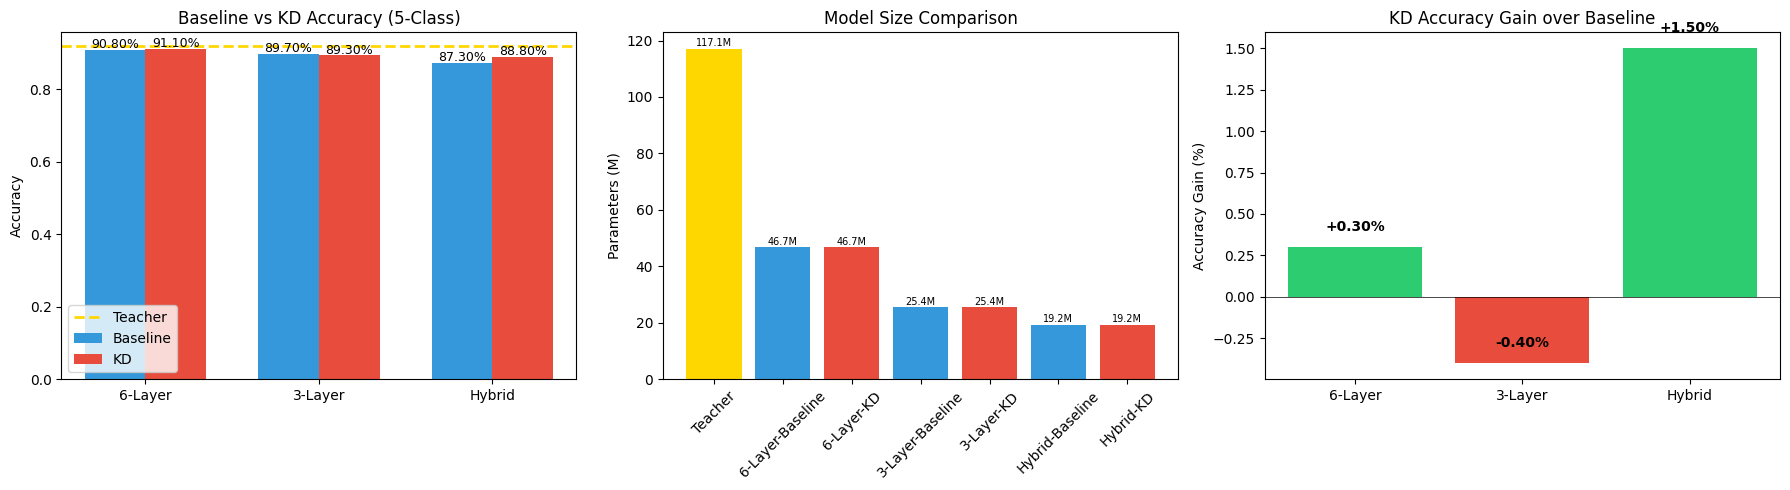

Chart saved to /kaggle/working/multiclass_kd_results.png

DARK KNOWLEDGE ANALYSIS
Average soft label entropy (T=5.0): 2.229 bits
Average hard label entropy (T=1):   0.598 bits
Max possible entropy (log2(5)): 2.322 bits
Binary case max entropy (log2(2)): 1.000 bits
Dark knowledge capacity ratio: 2.3x more informative


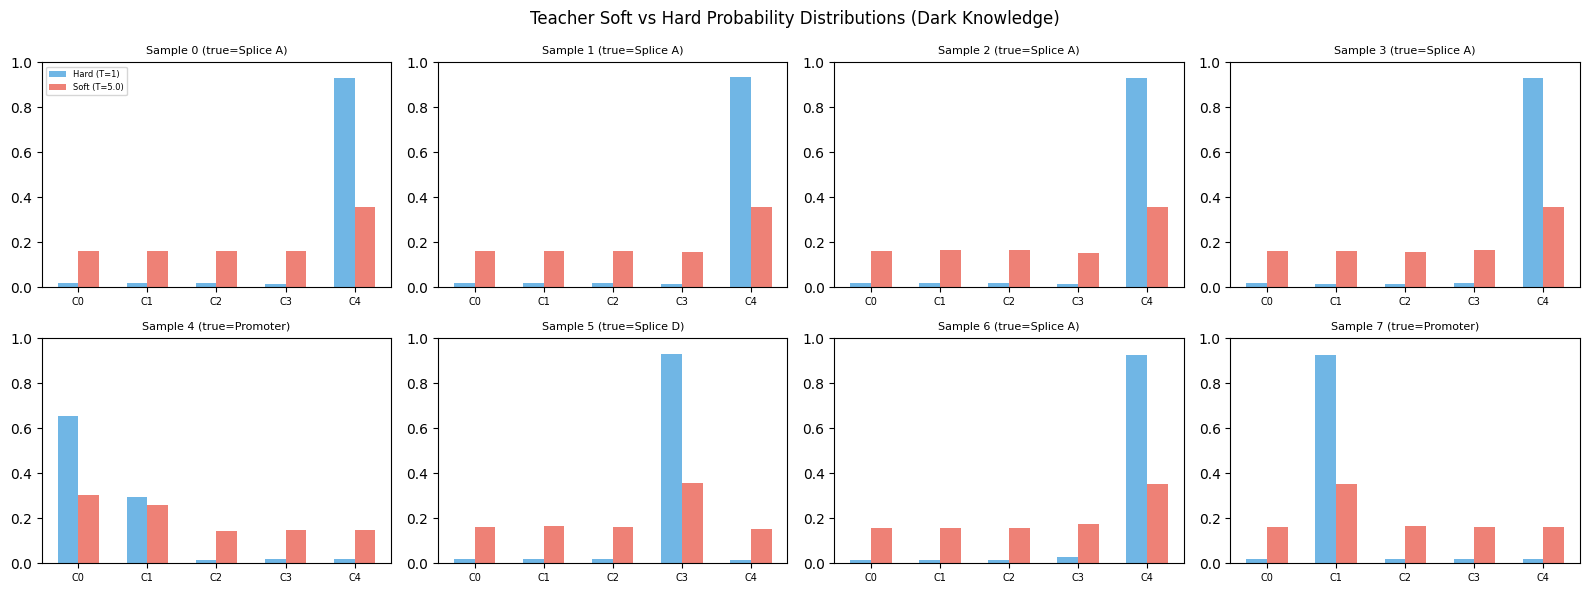

Results saved to /kaggle/working/multiclass_kd_results.json


In [7]:
import matplotlib.pyplot as plt

# ===== RESULTS TABLE =====
print("="*90)
print("MULTI-CLASS KNOWLEDGE DISTILLATION RESULTS (IMPROVED)")
print("="*90)
print(f"{'Model':<22} {'Accuracy':>10} {'F1-macro':>10} {'Params':>12} {'Time':>8}")
print("-"*90)

# Teacher
print(f"{'Teacher (DNABERT-2)':<22} {teacher_metrics['eval_accuracy']:>9.2%} {teacher_metrics['eval_f1_macro']:>10.4f} {teacher_params/1e6:>10.1f}M {'--':>8}")
print("-"*90)

for name, res in all_results.items():
    print(f"{name:<22} {res['accuracy']:>9.2%} {res['f1_macro']:>10.4f} {res['params']/1e6:>10.1f}M {res['train_time_min']:>6.1f}m")
print("="*90)

# ===== KD GAIN ANALYSIS =====
print("\nKNOWLEDGE DISTILLATION GAIN:")
archs = ["6-Layer", "3-Layer", "Hybrid"]
for arch in archs:
    bl_key = f"{arch}-Baseline"
    kd_key = f"{arch}-KD"
    if bl_key in all_results and kd_key in all_results:
        bl_acc = all_results[bl_key]["accuracy"]
        kd_acc = all_results[kd_key]["accuracy"]
        gain = kd_acc - bl_acc
        print(f"  {arch}: Baseline={bl_acc:.2%}, KD={kd_acc:.2%}, Gain={gain:+.2%}")

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Grouped bars: Baseline vs KD
present_archs = [a for a in archs if f"{a}-Baseline" in all_results and f"{a}-KD" in all_results]
x = np.arange(len(present_archs))
bar_width = 0.35
bl_accs = [all_results[f"{a}-Baseline"]["accuracy"] for a in present_archs]
kd_accs = [all_results[f"{a}-KD"]["accuracy"] for a in present_archs]

bars1 = axes[0].bar(x - bar_width/2, bl_accs, bar_width, label="Baseline", color="#3498db")
bars2 = axes[0].bar(x + bar_width/2, kd_accs, bar_width, label="KD", color="#e74c3c")
axes[0].axhline(y=teacher_metrics['eval_accuracy'], color="gold", linestyle="--", linewidth=2, label="Teacher")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline vs KD Accuracy (5-Class)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(present_archs)
axes[0].legend()
for bar, val in zip(bars1, bl_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.2%}", ha="center", fontsize=9)
for bar, val in zip(bars2, kd_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.2%}", ha="center", fontsize=9)

# 2. Model size comparison
all_names = ["Teacher"] + list(all_results.keys())
all_params_m = [teacher_params/1e6] + [all_results[n]["params"]/1e6 for n in all_results]
colors_list = ["gold"] + ["#3498db" if "Baseline" in n else "#e74c3c" for n in all_results]
bars3 = axes[1].bar(all_names, all_params_m, color=colors_list)
axes[1].set_ylabel("Parameters (M)")
axes[1].set_title("Model Size Comparison")
axes[1].tick_params(axis='x', rotation=45)
for bar, p in zip(bars3, all_params_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{p:.1f}M", ha="center", fontsize=7)

# 3. KD gain bar chart
gains = [all_results[f"{a}-KD"]["accuracy"] - all_results[f"{a}-Baseline"]["accuracy"] for a in present_archs]
gain_colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in gains]
bars4 = axes[2].bar(present_archs, [g * 100 for g in gains], color=gain_colors)
axes[2].set_ylabel("Accuracy Gain (%)")
axes[2].set_title("KD Accuracy Gain over Baseline")
axes[2].axhline(y=0, color="black", linewidth=0.5)
for bar, g in zip(bars4, gains):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{g:+.2%}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/multiclass_kd_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to /kaggle/working/multiclass_kd_results.png")

# ===== DARK KNOWLEDGE VISUALIZATION =====
print("\n" + "="*60)
print("DARK KNOWLEDGE ANALYSIS")
print("="*60)

# Run teacher on a test batch at T=TEMPERATURE
teacher_model.to(device)
test_batch_size = 8
test_batch = {k: eval_dataset[k][:test_batch_size].to(device) for k in ["input_ids", "attention_mask"]}

with torch.no_grad():
    teacher_out = teacher_model(**test_batch)
    soft_probs = F.softmax(teacher_out.logits / TEMPERATURE, dim=-1).cpu().numpy()
    hard_probs = F.softmax(teacher_out.logits, dim=-1).cpu().numpy()

# Compute entropy of soft labels
soft_entropy = -np.sum(soft_probs * np.log2(soft_probs + 1e-10), axis=-1)
hard_entropy = -np.sum(hard_probs * np.log2(hard_probs + 1e-10), axis=-1)

print(f"Average soft label entropy (T={TEMPERATURE}): {np.mean(soft_entropy):.3f} bits")
print(f"Average hard label entropy (T=1):   {np.mean(hard_entropy):.3f} bits")
print(f"Max possible entropy (log2({NUM_CLASSES})): {np.log2(NUM_CLASSES):.3f} bits")
print(f"Binary case max entropy (log2(2)): {np.log2(2):.3f} bits")
print(f"Dark knowledge capacity ratio: {np.log2(NUM_CLASSES)/np.log2(2):.1f}x more informative")

# Plot soft probability distributions for a few samples
fig, axes2 = plt.subplots(2, 4, figsize=(16, 6))
for i in range(min(test_batch_size, 8)):
    ax = axes2[i // 4][i % 4]
    true_label = eval_dataset["labels"][i].item()
    x_pos = np.arange(NUM_CLASSES)
    ax.bar(x_pos - 0.15, hard_probs[i], 0.3, label="Hard (T=1)", color="#3498db", alpha=0.7)
    ax.bar(x_pos + 0.15, soft_probs[i], 0.3, label=f"Soft (T={TEMPERATURE})", color="#e74c3c", alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"C{j}" for j in range(NUM_CLASSES)], fontsize=7)
    ax.set_title(f"Sample {i} (true={CLASS_NAMES[true_label][:8]})", fontsize=8)
    ax.set_ylim(0, 1.0)
    if i == 0:
        ax.legend(fontsize=6)

plt.suptitle("Teacher Soft vs Hard Probability Distributions (Dark Knowledge)", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/multiclass_dark_knowledge.png", dpi=150, bbox_inches="tight")
plt.show()

# Move teacher back to CPU to free GPU memory
teacher_model.cpu()
gc.collect()
torch.cuda.empty_cache()

# ===== SAVE RESULTS JSON =====
results_json = {
    "teacher_accuracy": teacher_metrics["eval_accuracy"],
    "teacher_f1_macro": teacher_metrics["eval_f1_macro"],
    "teacher_params": teacher_params,
    "improvements_applied": [
        "Teacher: frozen first 10/12 layers, label_smoothing=0.1, epochs reduced to 3",
        "Students: pretrained init from DNABERT-2 first-N layers (TinyBERT-style)",
        "KD: temperature increased to 5.0, alpha reduced to 0.3",
        "Data: oversampling with augmentation instead of undersampling",
        "Added 3-Layer-Standard architecture experiments",
    ],
    "students": all_results,
    "dark_knowledge": {
        "avg_soft_entropy": float(np.mean(soft_entropy)),
        "avg_hard_entropy": float(np.mean(hard_entropy)),
        "max_entropy_5class": float(np.log2(NUM_CLASSES)),
        "max_entropy_binary": float(np.log2(2)),
    },
}
with open("/kaggle/working/multiclass_kd_results.json", "w") as f:
    json.dump(results_json, f, indent=2)
print("Results saved to /kaggle/working/multiclass_kd_results.json")